# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [2]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [3]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [4]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 577.8711, Val Loss: 509.2218
Epoch 20/100, Train Loss: 392.3560, Val Loss: 384.4921
Epoch 30/100, Train Loss: 318.8099, Val Loss: 312.5139
Epoch 40/100, Train Loss: 249.9014, Val Loss: 246.8735
Epoch 50/100, Train Loss: 204.4797, Val Loss: 201.0890
Epoch 60/100, Train Loss: 183.1798, Val Loss: 182.1389
Epoch 70/100, Train Loss: 169.4769, Val Loss: 167.1420
Epoch 80/100, Train Loss: 153.8111, Val Loss: 154.1693
Epoch 90/100, Train Loss: 143.7904, Val Loss: 144.7674
Epoch 100/100, Train Loss: 137.6486, Val Loss: 137.5964
Test Loss: 135.9038


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

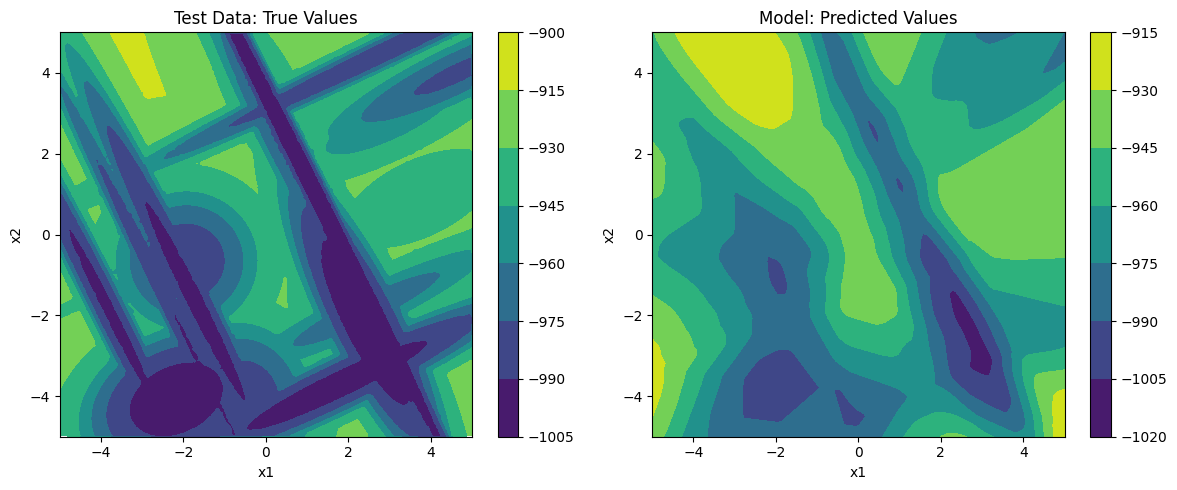

In [5]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

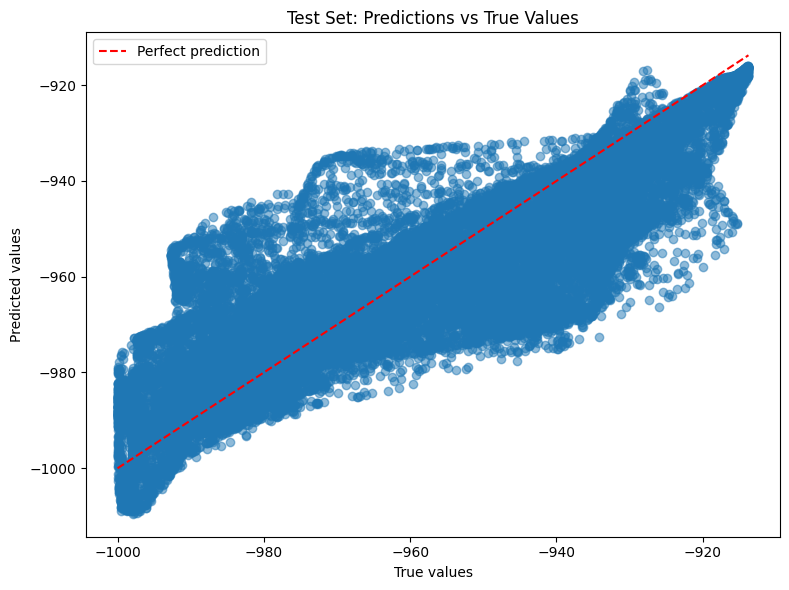

In [6]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [37]:
def optimize_model(
    model: nn.Module,
    x_min: torch.Tensor,
    x_max: torch.Tensor,
    num_steps: int = 1000,
    lr: float = 0.01,
) -> tuple[torch.Tensor, float]:
    """
    Run one gradient-based optimization from one random start.

    Returns:
        best_x: Best input found during this run.
        best_y: Best surrogate value found during this run.
    """
    model.eval()

    x_min = x_min.to(device)
    x_max = x_max.to(device)

    x0 = x_min + (x_max - x_min) * torch.rand(1, 2, device=device)
    x = nn.Parameter(x0)

    optimizer = torch.optim.Adam([x], lr=lr)

    best_x = x.detach().clone()
    best_y = float("inf")

    for _ in range(num_steps):
        optimizer.zero_grad()
        y = model(x)
        y.backward()
        optimizer.step()

        with torch.no_grad():
            x.clamp_(x_min, x_max)
            current_y = model(x).item()
            if current_y < best_y:
                best_y = current_y
                best_x = x.detach().clone()

    return best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [23]:
! pip install coco-experiment cocopp

In [9]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


In [22]:
def prepare_dataloaders_by_count(
    file_path: str,
    train_size: int,
    test_size: int = 30000,
    val_size: int | None = None,
    batch_size: int = 256,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train/validation/test dataloaders using exact sample counts.

    Args:
        file_path: Path to CSV data file.
        train_size: Number of training samples.
        test_size: Number of test samples.
        val_size: Number of validation samples. If None, uses train_size.
        batch_size: Batch size.
        seed: Random seed for reproducibility.
    """
    if val_size is None:
        val_size = train_size

    data_df = pd.read_csv(file_path)

    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    num_samples = len(X)
    required = train_size + val_size + test_size
    if required > num_samples:
        raise ValueError(
            f"Requested {required} samples, but dataset contains only {num_samples}."
        )

    rng = np.random.default_rng(seed)
    indices = rng.permutation(num_samples)

    train_idx = indices[:train_size]
    val_idx = indices[train_size : train_size + val_size]
    test_idx = indices[train_size + val_size : train_size + val_size + test_size]

    train_dataset = TensorDataset(X[train_idx], y[train_idx])
    val_dataset = TensorDataset(X[val_idx], y[val_idx])
    test_dataset = TensorDataset(X[test_idx], y[test_idx])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def get_xy_from_dataloader(dataloader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []
    for inputs, targets in dataloader:
        xs.append(inputs)
        ys.append(targets)
    X = torch.cat(xs, dim=0).numpy()
    y = torch.cat(ys, dim=0).numpy().reshape(-1)
    return X, y


def get_bounds_from_loader(dataloader: DataLoader) -> tuple[torch.Tensor, torch.Tensor]:
    X, _ = get_xy_from_dataloader(dataloader)
    x_min = torch.tensor(X.min(axis=0), dtype=torch.float32)
    x_max = torch.tensor(X.max(axis=0), dtype=torch.float32)
    return x_min, x_max

In [23]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]

        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

In [24]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 100,
    lr: float = 1e-3,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

    return train_losses, val_losses

In [25]:
def evaluate_regression_metrics(
    model: nn.Module,
    dataloader: DataLoader,
) -> dict:
    """
    Compute regression metrics on a dataloader.
    """
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu()

            y_true_list.append(targets)
            y_pred_list.append(outputs)

    y_true = torch.cat(y_true_list, dim=0).numpy().reshape(-1)
    y_pred = torch.cat(y_pred_list, dim=0).numpy().reshape(-1)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

In [26]:
def plot_learning_curves(
    train_losses: list[float],
    val_losses: list[float],
    title: str = "",
) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Curves {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_contour_comparison(
    model: nn.Module,
    reference_loader: DataLoader,
    title_suffix: str = "",
    grid_res: int = 150,
) -> None:
    """
    Plot true contour from sampled reference data and predicted contour from model.
    """
    X_ref, y_ref = get_xy_from_dataloader(reference_loader)

    x1_min, x1_max = X_ref[:, 0].min(), X_ref[:, 0].max()
    x2_min, x2_max = X_ref[:, 1].min(), X_ref[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, grid_res)
    x2_vals = np.linspace(x2_min, x2_max, grid_res)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack([X1.ravel(), X2.ravel()])
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        y_pred_grid = model(grid_tensor).cpu().numpy().reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    c1 = ax1.tricontourf(X_ref[:, 0], X_ref[:, 1], y_ref, levels=30)
    ax1.set_title(f"True Values {title_suffix}")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(c1, ax=ax1)

    c2 = ax2.contourf(X1, X2, y_pred_grid, levels=30)
    ax2.set_title(f"Predicted Values {title_suffix}")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(c2, ax=ax2)

    plt.tight_layout()
    plt.show()


def plot_metric_vs_dataset_size(results: list[dict], metric_name: str = "rmse") -> None:
    train_sizes = [r["train_size"] for r in results]
    metric_values = [r[metric_name] for r in results]

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, metric_values, marker="o")
    plt.xscale("log")
    plt.xlabel("Training Set Size")
    plt.ylabel(metric_name.upper())
    plt.title(f"{metric_name.upper()} vs Training Set Size")
    plt.tight_layout()
    plt.show()


def plot_optimization_histogram(best_y_array: np.ndarray, title: str = "") -> None:
    plt.figure(figsize=(7, 5))
    plt.hist(best_y_array, bins=10)
    plt.xlabel("Best Surrogate Value")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Optimization Results {title}")
    plt.tight_layout()
    plt.show()


def plot_solution_locations(
    model: nn.Module,
    reference_loader: DataLoader,
    best_x_array: np.ndarray,
    title: str = "",
    grid_res: int = 150,
) -> None:
    X_ref, _ = get_xy_from_dataloader(reference_loader)

    x1_min, x1_max = X_ref[:, 0].min(), X_ref[:, 0].max()
    x2_min, x2_max = X_ref[:, 1].min(), X_ref[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, grid_res)
    x2_vals = np.linspace(x2_min, x2_max, grid_res)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack([X1.ravel(), X2.ravel()])
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy().reshape(X1.shape)

    plt.figure(figsize=(7, 6))
    contour = plt.contourf(X1, X2, Z, levels=30)
    plt.scatter(best_x_array[:, 0], best_x_array[:, 1], marker="x", s=80)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Optimization Solutions on Surrogate Surface {title}")
    plt.colorbar(contour)
    plt.tight_layout()
    plt.show()


def compare_surrogate_and_true(best_y_array: np.ndarray, true_y_array: np.ndarray) -> None:
    plt.figure(figsize=(7, 6))
    plt.scatter(best_y_array, true_y_array, alpha=0.7)

    mn = min(best_y_array.min(), true_y_array.min())
    mx = max(best_y_array.max(), true_y_array.max())
    plt.plot([mn, mx], [mn, mx], "r--")

    plt.xlabel("Surrogate-Predicted Best y")
    plt.ylabel("True Objective Value")
    plt.title("Surrogate vs True Objective at Optimized Solutions")
    plt.tight_layout()
    plt.show()

    abs_error = np.abs(best_y_array - true_y_array)
    print(f"Mean absolute error: {abs_error.mean():.6f}")
    print(f"Std absolute error:  {abs_error.std():.6f}")

In [34]:
def run_dataset_size_experiment(
    file_path: str,
    train_sizes: list[int],
    test_size: int = 30000,
    val_size: int = 10000,
    hidden_dim: int = 256,
    n_layers: int = 3,
    num_epochs: int = 100,
    lr: float = 1e-3,
    batch_size: int = 256,
) -> tuple[list[dict], dict[int, nn.Module]]:
    results = []
    trained_models = {}

    for train_size in train_sizes:
        print("\n" + "=" * 70)
        print(f"Training with train_size = {train_size}")
        print("=" * 70)

        train_loader, val_loader, test_loader = prepare_dataloaders_by_count(
            file_path=file_path,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
            batch_size=batch_size,
            seed=42,
        )

        model = MLP(hidden_dim=hidden_dim, n_layers=n_layers).to(device)

        train_losses, val_losses = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=num_epochs,
            lr=lr,
        )

        metrics = evaluate_regression_metrics(model, test_loader)
        print(
            f"Test RMSE: {metrics['rmse']:.6f} | "
            f"Test MAE: {metrics['mae']:.6f} | "
            f"Test R²: {metrics['r2']:.6f}"
        )

        plot_learning_curves(
            train_losses,
            val_losses,
            title=f"(train size = {train_size})",
        )

        plot_contour_comparison(
            model,
            test_loader,
            title_suffix=f"(train size = {train_size})",
        )

        result = {
            "train_size": train_size,
            "rmse": metrics["rmse"],
            "mse": metrics["mse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "train_loader": train_loader,
            "val_loader": val_loader,
            "test_loader": test_loader,
            "train_losses": train_losses,
            "val_losses": val_losses,
        }

        results.append(result)
        trained_models[train_size] = model

    return results, trained_models

In [28]:
def run_optimization_experiment(
    model: nn.Module,
    reference_loader: DataLoader,
    n_runs: int = 10,
    num_steps: int = 1000,
    lr: float = 0.01,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Run optimize_model multiple times and collect solutions.
    """
    x_min, x_max = get_bounds_from_loader(reference_loader)

    best_x_list = []
    best_y_list = []

    for run_idx in range(n_runs):
        best_x, best_y = optimize_model(
            model=model,
            x_min=x_min,
            x_max=x_max,
            num_steps=num_steps,
            lr=lr,
        )
        best_x_list.append(best_x.cpu().numpy().reshape(-1))
        best_y_list.append(best_y)

        print(f"Optimization run {run_idx + 1:2d}/{n_runs}: best surrogate y = {best_y:.6f}")

    best_x_array = np.array(best_x_list)
    best_y_array = np.array(best_y_list)

    return best_x_array, best_y_array

In [29]:
def get_bbob_function(function_id: int = 22, dimension: int = 2, instance: int = 1):
    """
    Use the exact Suite setup requested by the exercise.
    """
    suite = Suite(
        "bbob",
        "",
        f"function_indices: {function_id}, dimensions: {dimension} instance_indices: {instance}",
    )

    for function in suite:
        print(function.info)
        print("Function value at (0, 0):", function(np.array([0, 0])))
        return function

    raise ValueError("No function found in suite.")


def evaluate_true_objective_on_solutions(
    best_x_array: np.ndarray,
    function_id: int = 22,
    dimension: int = 2,
    instance: int = 1,
) -> np.ndarray:
    """
    Evaluate the true BBOB objective at optimized solution points.
    """
    function = get_bbob_function(
        function_id=function_id,
        dimension=dimension,
        instance=instance,
    )

    true_values = np.array([function(x) for x in best_x_array])
    return true_values


Training with train_size = 100
Test RMSE: 436.262299 | Test MAE: 392.224335 | Test R²: -313.582336


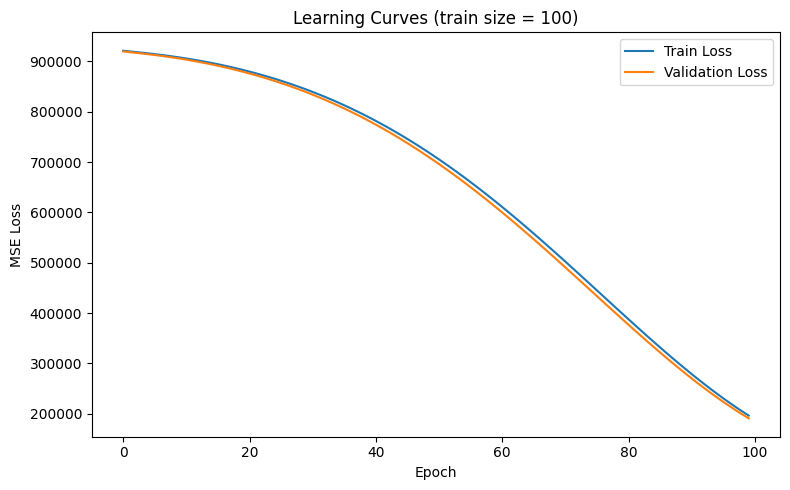

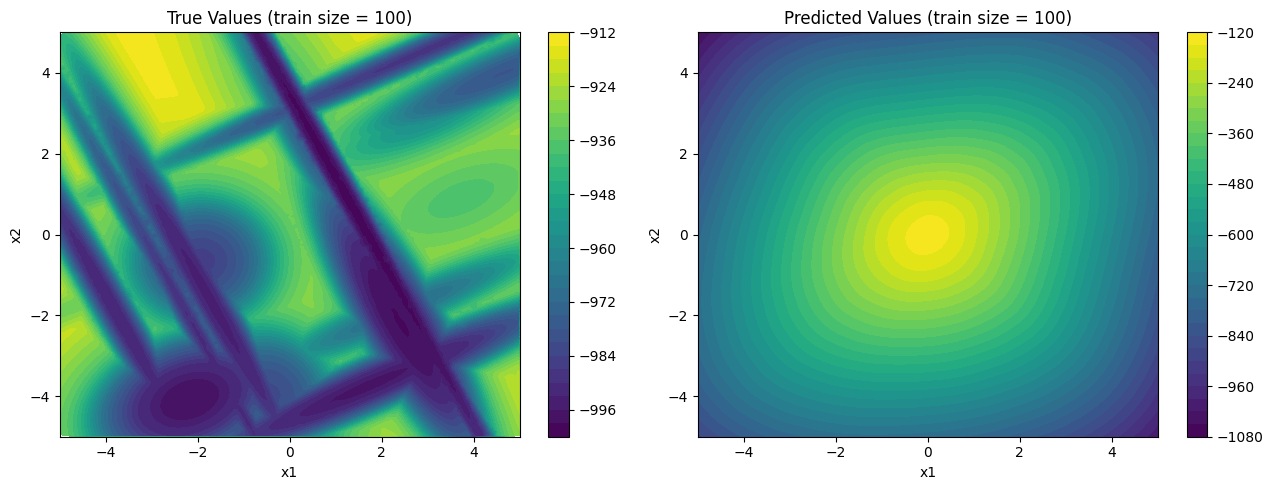


Training with train_size = 1000
Test RMSE: 230.158508 | Test MAE: 187.094955 | Test R²: -86.594208


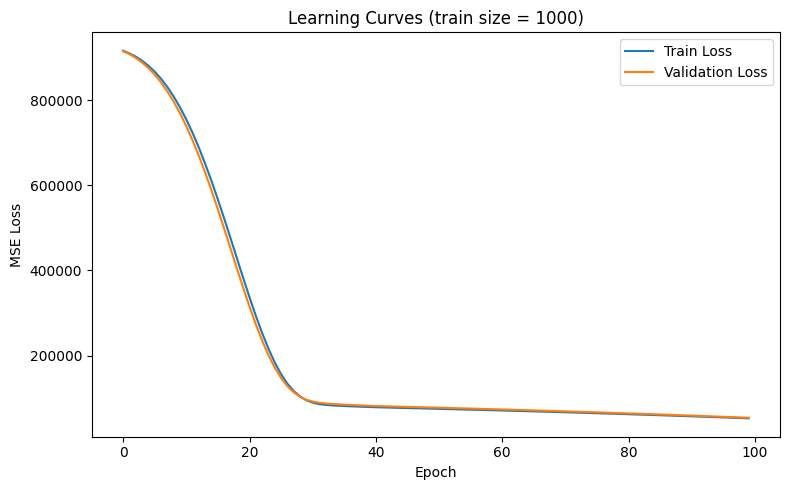

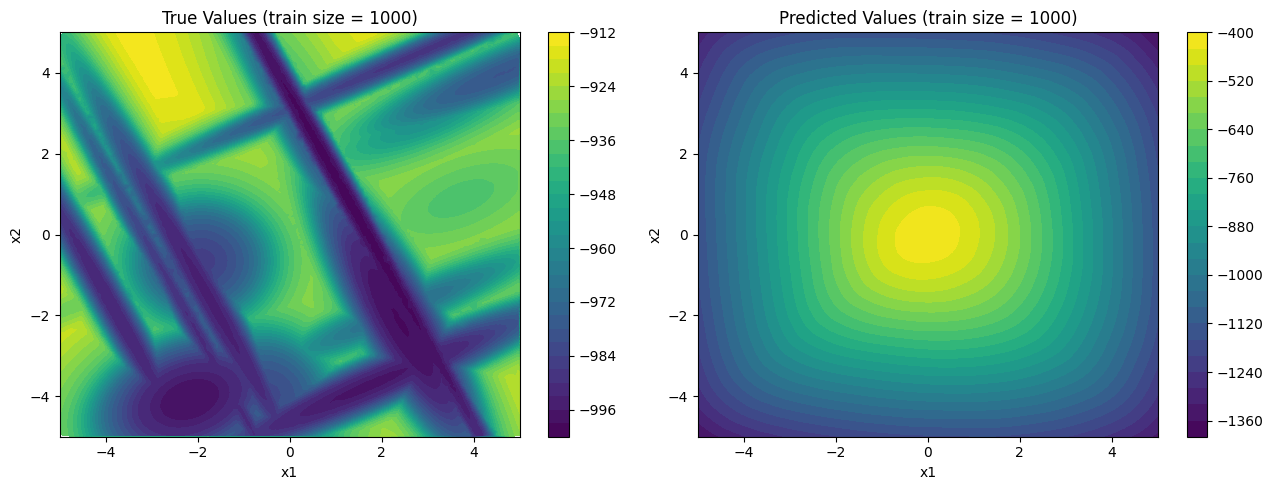


Training with train_size = 5000
Test RMSE: 18.838842 | Test MAE: 15.424219 | Test R²: 0.413922


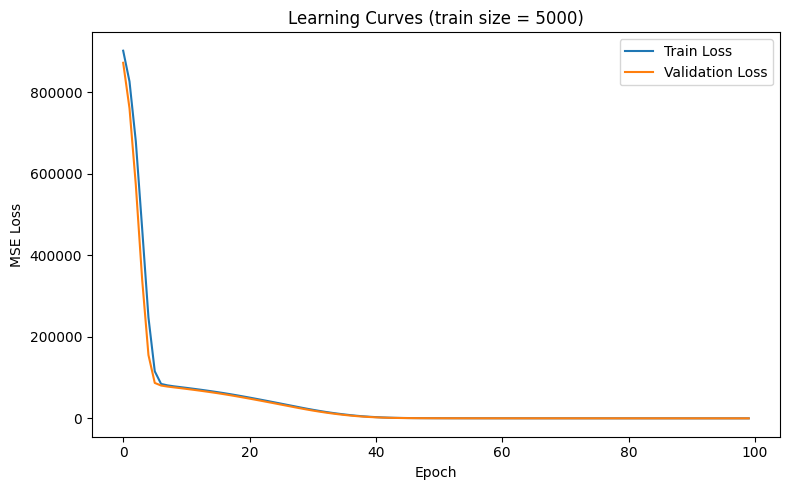

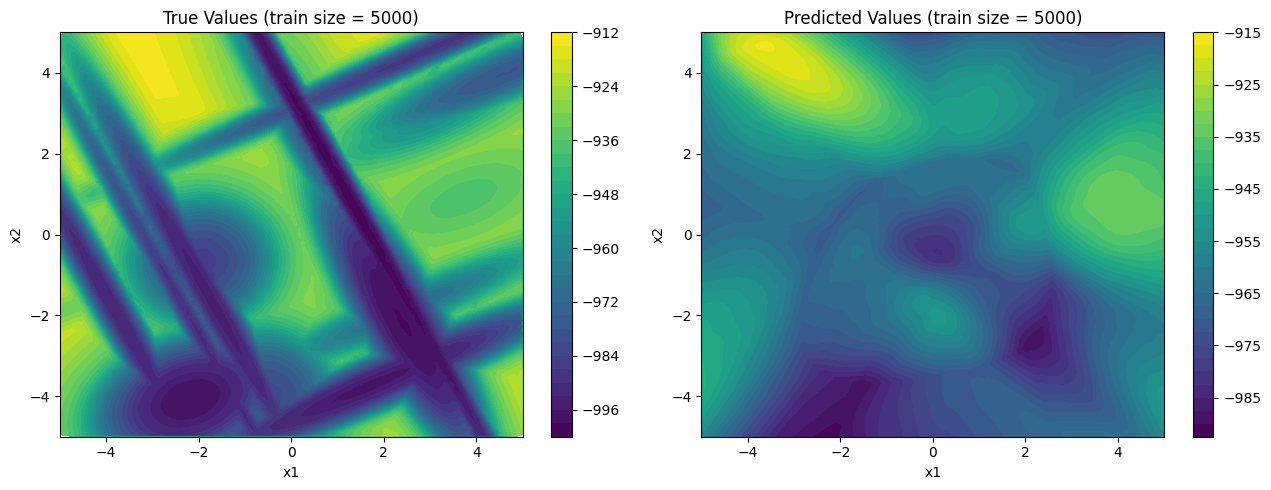


Training with train_size = 10000
Test RMSE: 15.652318 | Test MAE: 12.813271 | Test R²: 0.597307


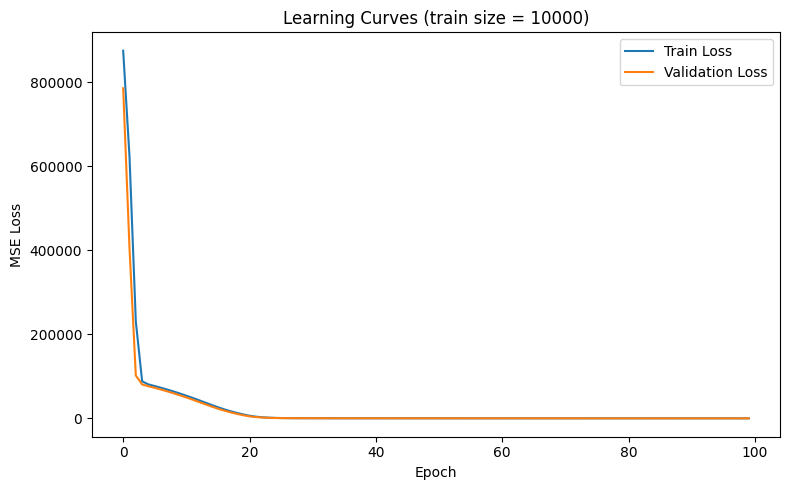

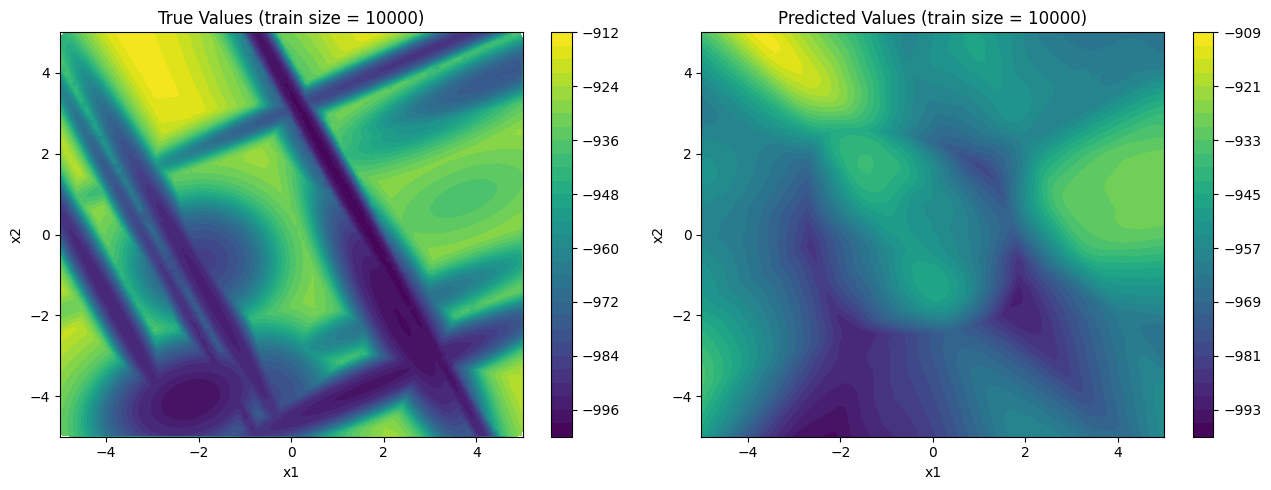


Training with train_size = 50000
Test RMSE: 11.747598 | Test MAE: 8.725601 | Test R²: 0.774430


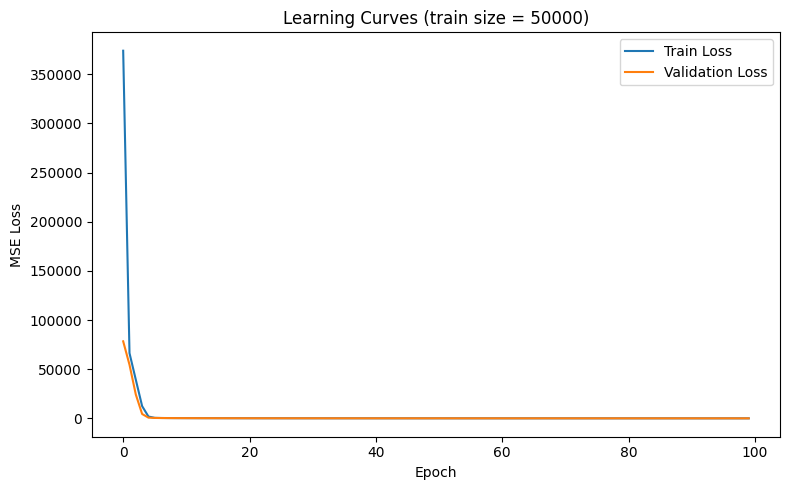

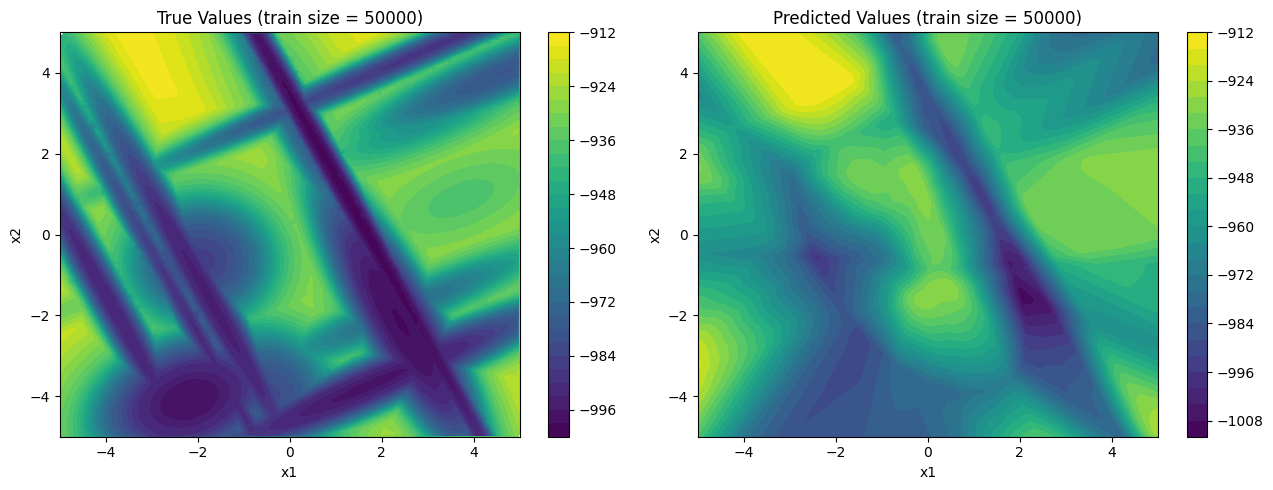

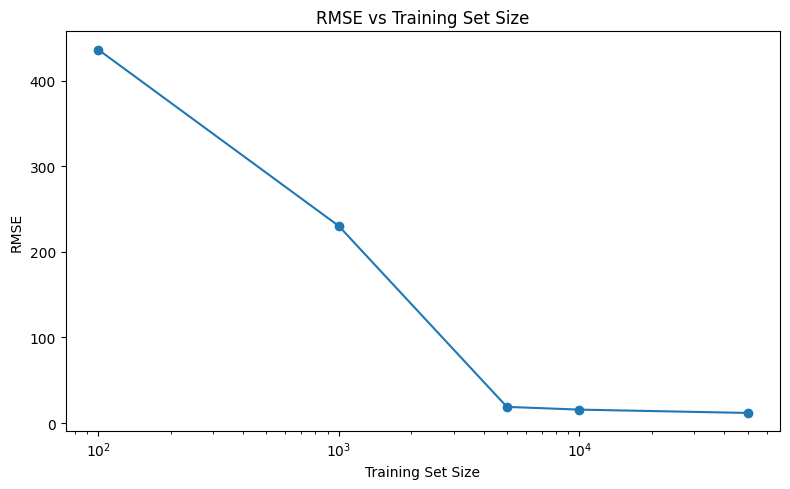


Summary of Exercise 1:
train_size=   100 | RMSE=436.262299 | MAE=392.224335 | R²=-313.582336
train_size=  1000 | RMSE=230.158508 | MAE=187.094955 | R²=-86.594208
train_size=  5000 | RMSE=18.838842 | MAE=15.424219 | R²=0.413922
train_size= 10000 | RMSE=15.652318 | MAE=12.813271 | R²=0.597307
train_size= 50000 | RMSE=11.747598 | MAE=8.725601 | R²=0.774430


In [35]:
file_path = "./bbob_f022_i01_d02_samples.csv"

# ----------------------------
# Exercise 1
# ----------------------------
train_sizes = [100, 1000, 5000, 10000, 50000]

results, trained_models = run_dataset_size_experiment(
    file_path=file_path,
    train_sizes=[100, 1000, 5000, 10000, 50000],
    test_size=30000,
    val_size=10000,
    hidden_dim=256,
    n_layers=3,
    num_epochs=100,
    lr=1e-3,
    batch_size=256,
)
# Use RMSE as the single quantitative metric
plot_metric_vs_dataset_size(results, metric_name="rmse")

print("\nSummary of Exercise 1:")
for r in results:
    print(
        f"train_size={r['train_size']:6d} | "
        f"RMSE={r['rmse']:.6f} | "
        f"MAE={r['mae']:.6f} | "
        f"R²={r['r2']:.6f}"
    )



######################################################################
Optimization robustness for train_size = 100
######################################################################
Optimization run  1/10: best surrogate y = -911.704956
Optimization run  2/10: best surrogate y = -1041.531616
Optimization run  3/10: best surrogate y = -1012.852722
Optimization run  4/10: best surrogate y = -1012.852722
Optimization run  5/10: best surrogate y = -874.525513
Optimization run  6/10: best surrogate y = -1012.852722
Optimization run  7/10: best surrogate y = -874.525513
Optimization run  8/10: best surrogate y = -874.525513
Optimization run  9/10: best surrogate y = -1012.852722
Optimization run 10/10: best surrogate y = -1041.531616


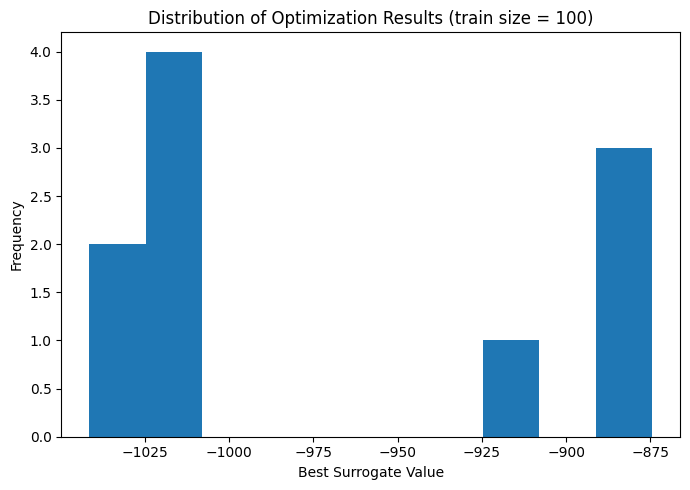

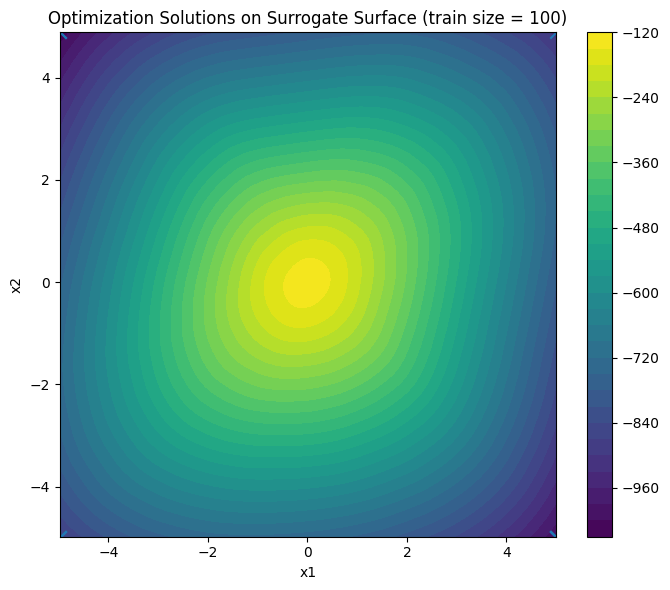

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


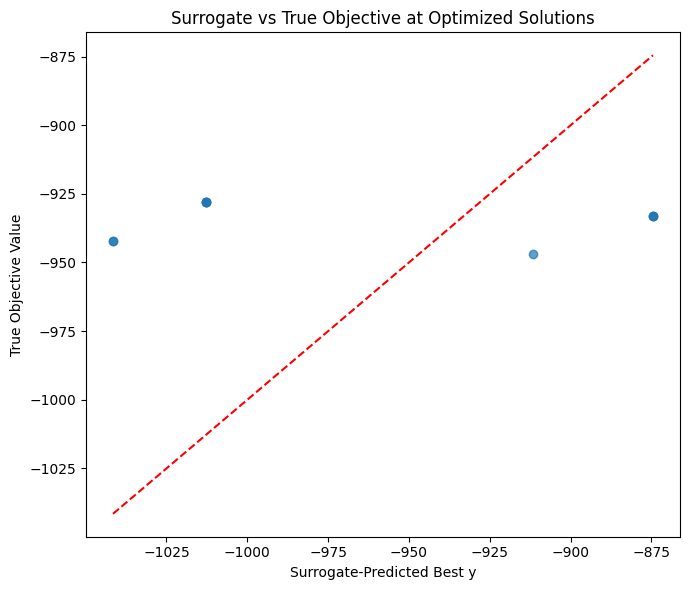

Mean absolute error: 74.905754
Std absolute error:  19.914022

Best surrogate values:
[ -911.70495605 -1041.53161621 -1012.85272217 -1012.85272217
  -874.5255127  -1012.85272217  -874.5255127   -874.5255127
 -1012.85272217 -1041.53161621]

True objective values at optimized points:
[-946.93764745 -942.32758127 -927.88498203 -927.88498203 -933.04078677
 -927.88498203 -933.04078677 -933.04078677 -927.88498203 -942.32758127]

Mean surrogate best value: -966.975562
Std surrogate best value:  69.449219
Mean true objective value: -934.225510
Std true objective value:  6.766871

######################################################################
Optimization robustness for train_size = 1000
######################################################################
Optimization run  1/10: best surrogate y = -1332.288574
Optimization run  2/10: best surrogate y = -1332.288574
Optimization run  3/10: best surrogate y = -1366.998291
Optimization run  4/10: best surrogate y = -1361.541382
Optimizat

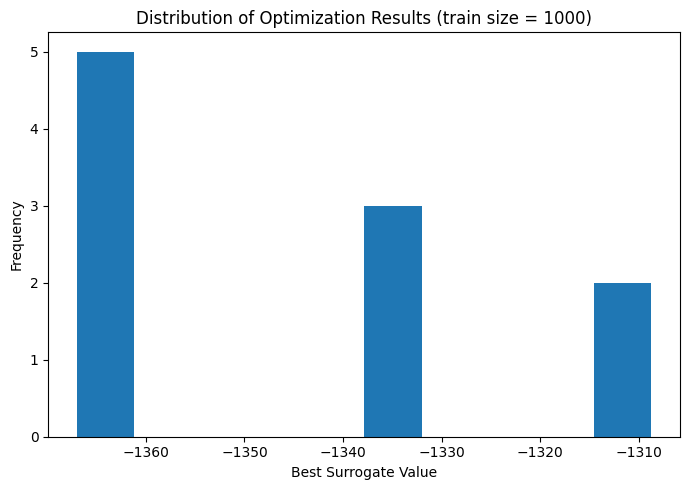

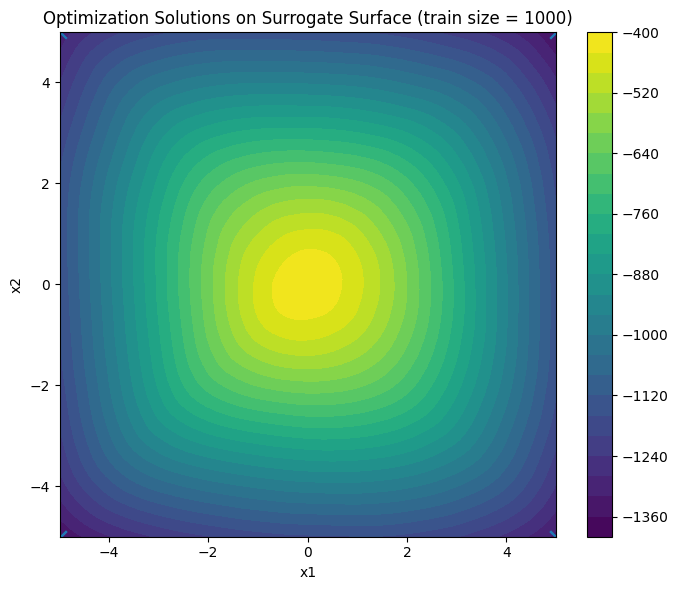

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


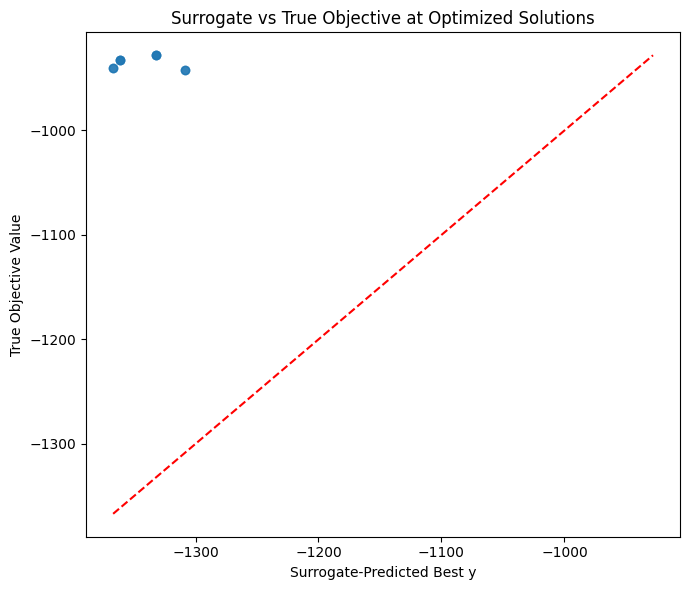

Mean absolute error: 408.647979
Std absolute error:  23.168904

Best surrogate values:
[-1332.28857422 -1332.28857422 -1366.99829102 -1361.54138184
 -1361.54138184 -1308.73059082 -1308.73059082 -1332.28857422
 -1361.54138184 -1366.99829102]

True objective values at optimized points:
[-927.96962712 -927.96962712 -940.32736793 -932.85895896 -932.85895896
 -941.66367448 -941.66367448 -927.96962712 -932.85895896 -940.32736793]

Mean surrogate best value: -1343.294763
Std surrogate best value:  22.080091
Mean true objective value: -934.646784
Std true objective value:  5.534924

######################################################################
Optimization robustness for train_size = 5000
######################################################################
Optimization run  1/10: best surrogate y = -982.944641
Optimization run  2/10: best surrogate y = -972.359680
Optimization run  3/10: best surrogate y = -969.585876
Optimization run  4/10: best surrogate y = -969.585815
Optimizati

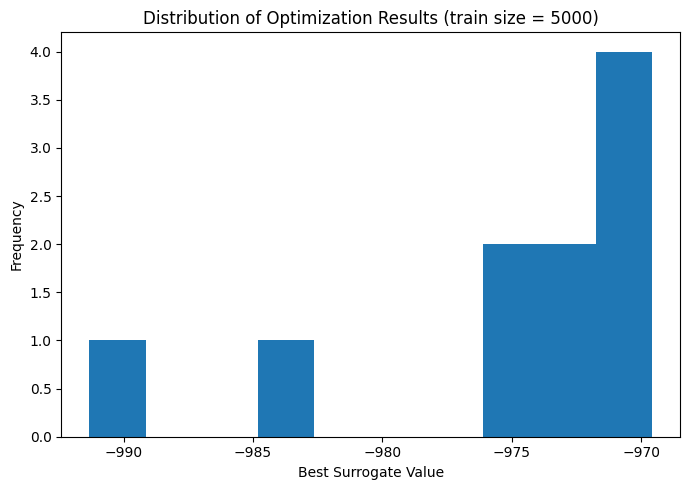

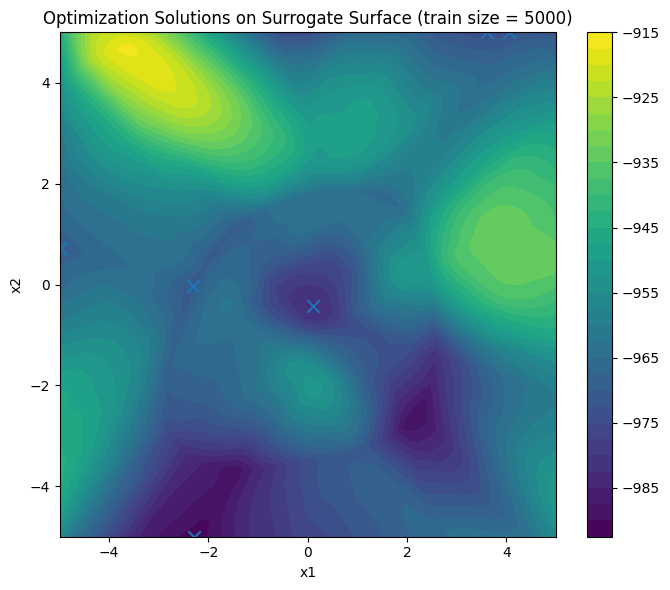

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


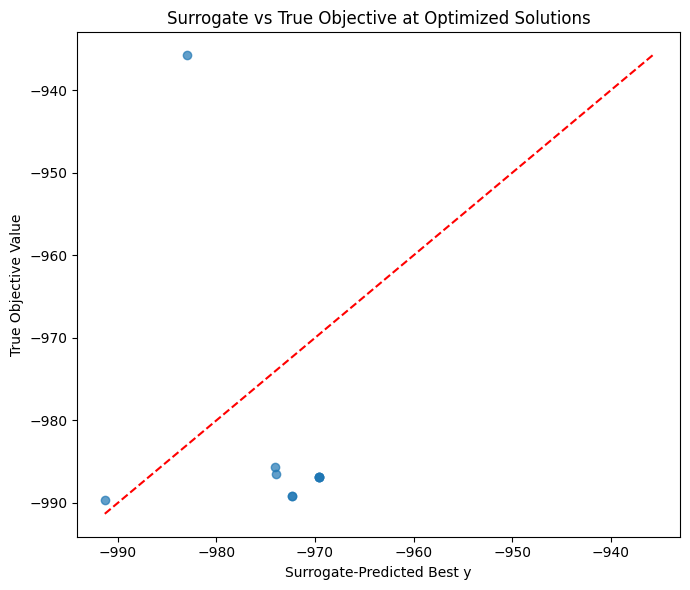

Mean absolute error: 17.577955
Std absolute error:  10.926329

Best surrogate values:
[-982.94464111 -972.35968018 -969.58587646 -969.58581543 -974.05712891
 -973.93756104 -969.58587646 -991.32519531 -969.58581543 -972.35986328]

True objective values at optimized points:
[-935.7372757  -989.19392299 -986.85306556 -986.85310912 -985.63216984
 -986.56025391 -986.8530919  -989.67991985 -986.853021   -989.18589425]

Mean surrogate best value: -974.532745
Std surrogate best value:  6.787177
Mean true objective value: -982.340172
Std true objective value:  15.587338

######################################################################
Optimization robustness for train_size = 10000
######################################################################
Optimization run  1/10: best surrogate y = -979.953186
Optimization run  2/10: best surrogate y = -996.590454
Optimization run  3/10: best surrogate y = -979.952637
Optimization run  4/10: best surrogate y = -996.590454
Optimization run  5/10

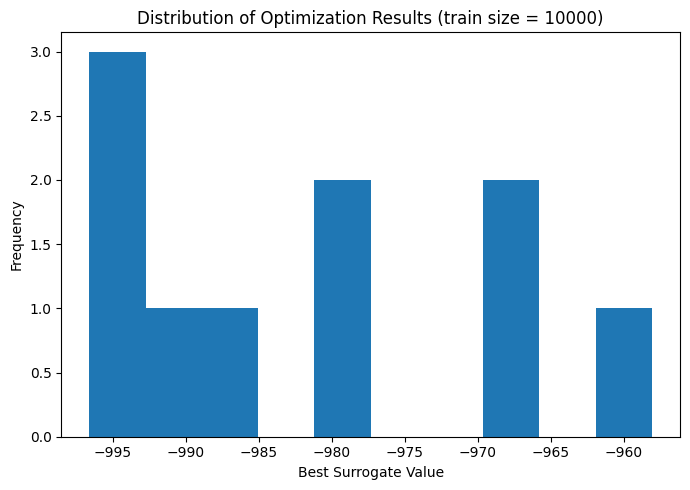

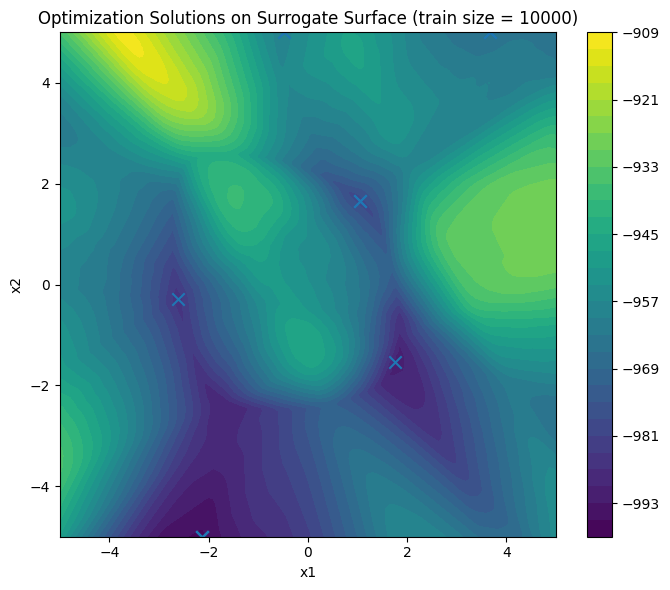

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


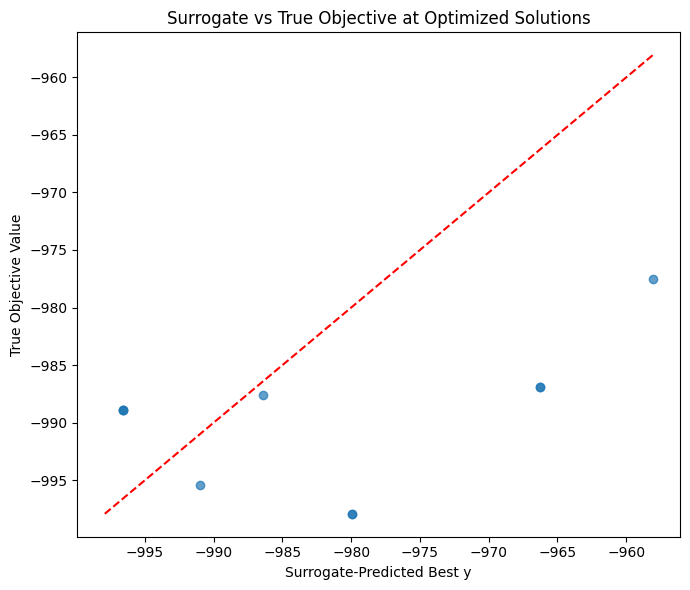

Mean absolute error: 12.541545
Std absolute error:  7.093413

Best surrogate values:
[-979.95318604 -996.5904541  -979.95263672 -996.5904541  -966.2434082
 -990.97973633 -986.394104   -958.08337402 -996.5904541  -966.2434082 ]

True objective values at optimized points:
[-997.91993975 -988.87258375 -997.91793253 -988.87267234 -986.89151532
 -995.39061655 -987.56689272 -977.53283987 -988.87234306 -986.89180027]

Mean surrogate best value: -981.762122
Std surrogate best value:  13.472003
Mean true objective value: -989.672914
Std true objective value:  5.812875

######################################################################
Optimization robustness for train_size = 50000
######################################################################
Optimization run  1/10: best surrogate y = -1010.332825
Optimization run  2/10: best surrogate y = -965.752197
Optimization run  3/10: best surrogate y = -978.949463
Optimization run  4/10: best surrogate y = -989.826721
Optimization run  5/10:

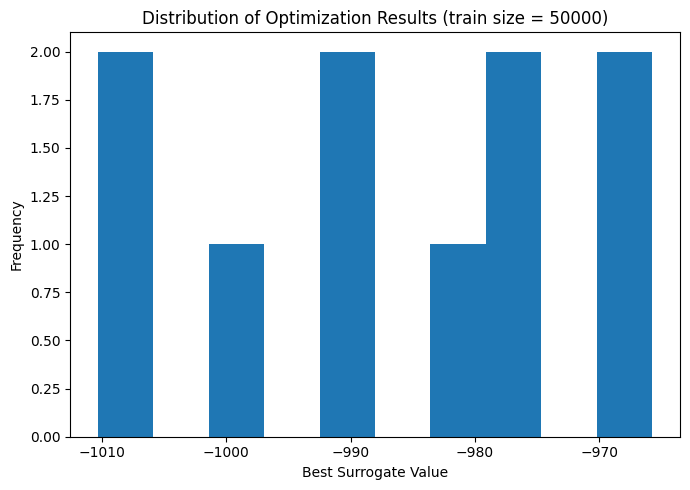

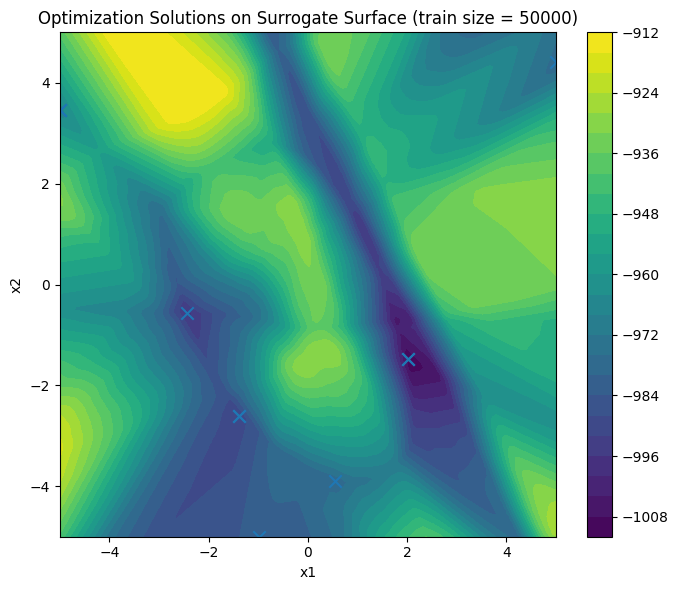

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


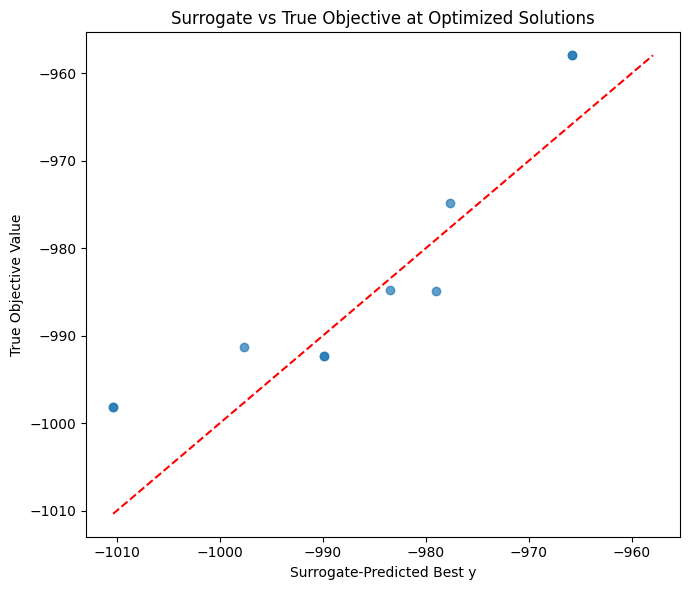

Mean absolute error: 6.133148
Std absolute error:  3.757810

Best surrogate values:
[-1010.33282471  -965.75219727  -978.94946289  -989.82672119
  -977.652771    -989.82720947  -997.6171875   -965.75219727
  -983.44396973 -1010.33306885]

True objective values at optimized points:
[-998.12954297 -957.92327692 -984.81223375 -992.25278027 -974.78609253
 -992.25472139 -991.22107568 -957.92386756 -984.73193695 -998.12921728]

Mean surrogate best value: -986.948761
Std surrogate best value:  15.117209
Mean true objective value: -983.216475
Std true objective value:  14.239326


In [38]:
# ----------------------------
# Exercise 2
# ----------------------------
optimization_results = {}

for train_size in train_sizes:
    print("\n" + "#" * 70)
    print(f"Optimization robustness for train_size = {train_size}")
    print("#" * 70)

    model = trained_models[train_size]
    train_loader = next(r["train_loader"] for r in results if r["train_size"] == train_size)

    best_x_array, best_y_array = run_optimization_experiment(
        model=model,
        reference_loader=train_loader,
        n_runs=10,
        num_steps=1000,
        lr=0.01,
    )

    plot_optimization_histogram(
        best_y_array,
        title=f"(train size = {train_size})",
    )

    plot_solution_locations(
        model=model,
        reference_loader=train_loader,
        best_x_array=best_x_array,
        title=f"(train size = {train_size})",
    )

    true_y_array = evaluate_true_objective_on_solutions(
        best_x_array,
        function_id=22,
        dimension=2,
        instance=1,
    )

    compare_surrogate_and_true(best_y_array, true_y_array)

    optimization_results[train_size] = {
        "best_x_array": best_x_array,
        "best_y_array": best_y_array,
        "true_y_array": true_y_array,
    }

    print("\nBest surrogate values:")
    print(best_y_array)

    print("\nTrue objective values at optimized points:")
    print(true_y_array)

    print(
        f"\nMean surrogate best value: {best_y_array.mean():.6f}\n"
        f"Std surrogate best value:  {best_y_array.std():.6f}\n"
        f"Mean true objective value: {true_y_array.mean():.6f}\n"
        f"Std true objective value:  {true_y_array.std():.6f}"
    )